In [3]:
%load_ext autoreload
%autoreload 2

In [11]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

import torch
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_trainer.model_utils import SparseAutoencoder
from sae_trainer.feature_tracer_utils import FeatureTracer, TraceConfig

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForCausalLM.from_pretrained(model_name).to(device).eval()

# Load SAE checkpoint — pick whichever layer you want to analyse (3, 6, 9, or 11)
ckpt = torch.load("sae_gpt2_layer9.pt", map_location=device)
sae = SparseAutoencoder(d_in=ckpt["d_in"], d_latent=ckpt["d_latent"], normalize_decoder=True).to(device)
sae.load_state_dict(ckpt["model_state"])
sae.eval()


In [ ]:
# 4) Tracer config — layer_idx MUST match the checkpoint loaded above
cfg = TraceConfig(
    layer_idx=9,
    topk_per_token=8,
    min_activation=0.01,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7,
)
tracer = FeatureTracer(llm, tokenizer, sae, device, cfg)


In [23]:
# 5) Run tracing
#summaries = tracer.trace_prompts([
#    "Explain sparse autoencoders in simple terms.",
#    "Write a short poem about Paris and geometry.",
#    "Why do transformers use attention?"
#])
summaries = tracer.trace_prompts([
    "My name is Miles. What is my name?",
    "My name tag says Miles. What is my name?",
    "My friend told me: 'Miles, come here and see this!'. What is my name?"
])
summaries

[{'prompt_id': 'p0',
  'prompt': 'My name is Miles. What is my name?',
  'generated_text': 'My name is Miles. What is my name? My name is Miles.\n\nThe plural form of the word "name" is "names". \n\nSo, "my name" is "my names", and "your name" is "our names". The question mark at the end means that there are no additional questions or answers to ask about your name. If you have any other questions or need more information about your name, feel free to ask!',
  'num_tokens': 90,
  'num_hits': 1424},
 {'prompt_id': 'p1',
  'prompt': 'My name tag says Miles. What is my name?',
  'generated_text': 'My name tag says Miles. What is my name? My name is Miles. How do I say it? It\'s "M." Miles. How can I get to the airport? I can go there by bus or taxi. Which one would you like to take? I\'d prefer a taxi. But if you\'re coming from my house, then you should use the bus. So which one should I choose? The bus. How long does the ride',
  'num_tokens': 91,
  'num_hits': 1424},
 {'prompt_id': 'p2

In [24]:
# 6) Inspect
df = tracer.to_dataframe()
display(df.head())

display(tracer.top_features(20))

# replace with a real feature id from top_features output
#display(tracer.feature_contexts(feature_id=int(tracer.top_features(1).iloc[0]["feature_id"]), top_n=10))

#tracer.save_csv("feature_hits.csv")

,prompt_id,prompt,generated_text,token_pos,token,feature_id,activation
0,p0,Explain sparse autoencoders in simple terms.,Explain sparse autoencoders in simple terms. A...,0,Ex,6385,66.602928
1,p0,Explain sparse autoencoders in simple terms.,Explain sparse autoencoders in simple terms. A...,0,Ex,1387,61.424305
2,p0,Explain sparse autoencoders in simple terms.,Explain sparse autoencoders in simple terms. A...,0,Ex,4575,61.181168
3,p0,Explain sparse autoencoders in simple terms.,Explain sparse autoencoders in simple terms. A...,0,Ex,5233,60.795635
4,p0,Explain sparse autoencoders in simple terms.,Explain sparse autoencoders in simple terms. A...,0,Ex,6547,58.975372


,feature_id,hits,mean_activation,max_activation
0,3187,55,2.513677,3.017200
1,826,49,2.674702,3.750982
2,2059,44,2.699457,3.480039
3,6215,41,2.750761,3.227339
4,290,38,2.587926,3.632933
5,6977,37,2.687417,3.357393
6,6405,36,2.704533,3.418120
7,347,33,2.666823,3.312558
8,944,31,2.746992,3.439548
9,5802,31,2.591291,3.091270


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

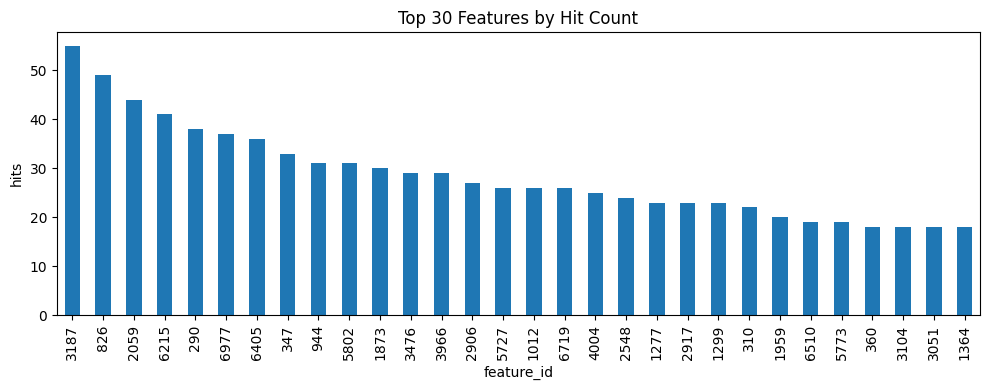

In [26]:
# 1) Top features by hit count
top_n = 30
counts = (df.groupby("feature_id").size().sort_values(ascending=False).head(top_n))
plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.title(f"Top {top_n} Features by Hit Count")
plt.xlabel("feature_id")
plt.ylabel("hits")
plt.tight_layout()
plt.show()

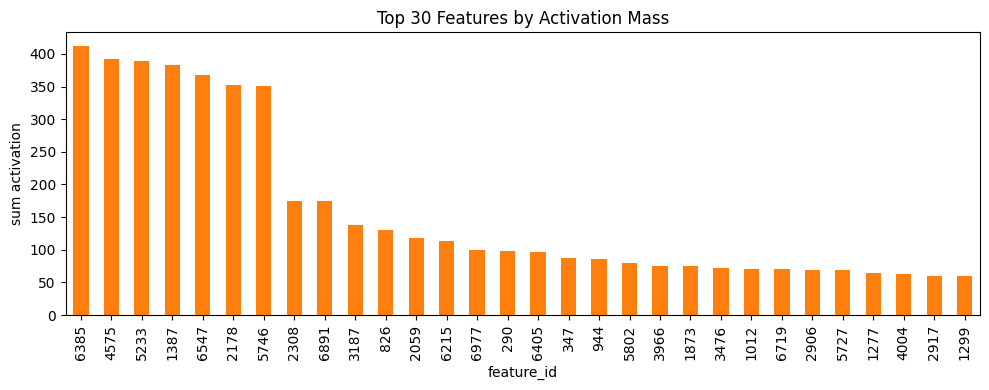

In [27]:
# 2) Top features by activation mass
top_n = 30
mass = (df.groupby("feature_id")["activation"].sum().sort_values(ascending=False).head(top_n))
plt.figure(figsize=(10,4))
mass.plot(kind="bar", color="tab:orange")
plt.title(f"Top {top_n} Features by Activation Mass")
plt.xlabel("feature_id")
plt.ylabel("sum activation")
plt.tight_layout()
plt.show()

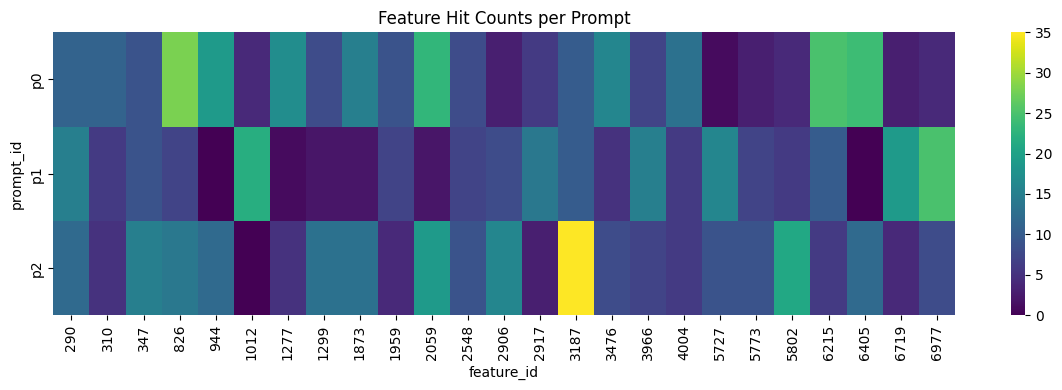

In [28]:
# 3) Prompt x feature heatmap (counts)
top_features = df["feature_id"].value_counts().head(25).index
heat = (df[df["feature_id"].isin(top_features)]
        .pivot_table(index="prompt_id", columns="feature_id", values="activation", aggfunc="count", fill_value=0))
plt.figure(figsize=(12,4))
sns.heatmap(heat, cmap="viridis")
plt.title("Feature Hit Counts per Prompt")
plt.xlabel("feature_id")
plt.ylabel("prompt_id")
plt.tight_layout()
plt.show()

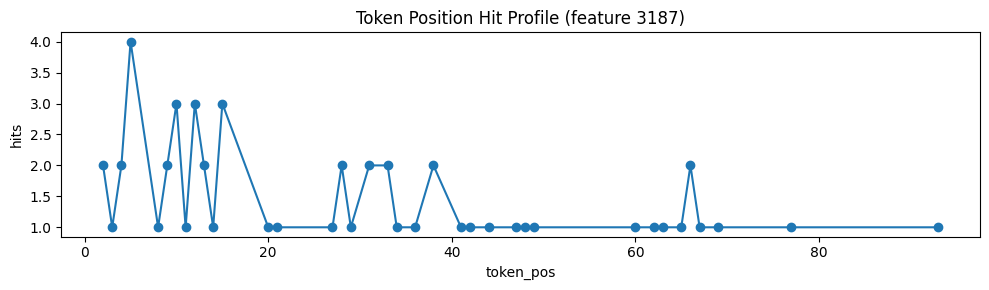

In [29]:
# 4) Token position profile for one feature
feature_id = int(df["feature_id"].value_counts().index[0])  # pick most frequent
sub = df[df["feature_id"] == feature_id]
pos_counts = sub["token_pos"].value_counts().sort_index()

plt.figure(figsize=(10,3))
plt.plot(pos_counts.index, pos_counts.values, marker="o")
plt.title(f"Token Position Hit Profile (feature {feature_id})")
plt.xlabel("token_pos")
plt.ylabel("hits")
plt.tight_layout()
plt.show()

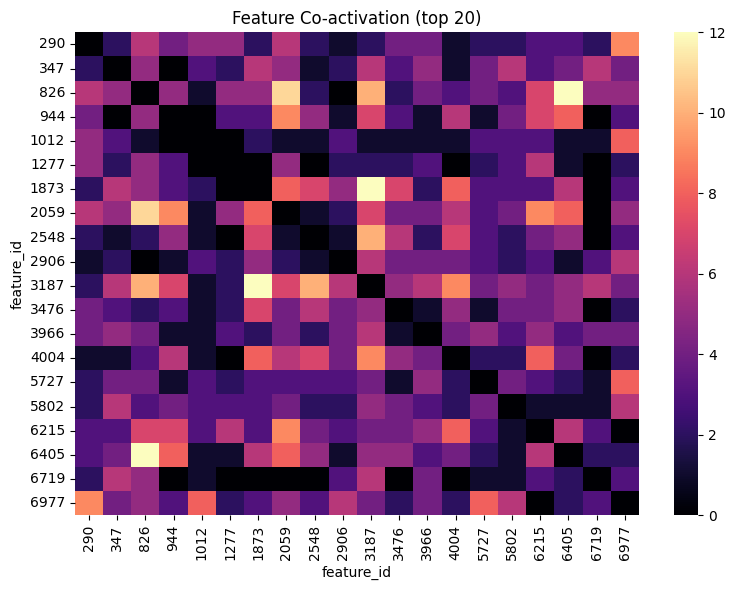

In [30]:
# 5) Co-activation matrix on top features (same prompt_id + token_pos)
top_m = 20
top_feats = df["feature_id"].value_counts().head(top_m).index.tolist()

pairs = df[df["feature_id"].isin(top_feats)][["prompt_id","token_pos","feature_id"]].drop_duplicates()
mat = pd.crosstab(index=[pairs["prompt_id"], pairs["token_pos"]], columns=pairs["feature_id"]).astype(float)
co = mat.T @ mat  # co-occurrence counts
np.fill_diagonal(co.values, 0)

plt.figure(figsize=(8,6))
sns.heatmap(co, cmap="magma")
plt.title(f"Feature Co-activation (top {top_m})")
plt.xlabel("feature_id")
plt.ylabel("feature_id")
plt.tight_layout()
plt.show()

In [ ]:
import html as html_lib
from IPython.display import HTML, display as ipy_display
import matplotlib.pyplot as plt


def render_feature_card(
    feature_id: int,
    tracer,
    top_n: int = 10,
    window: int = 8,
    tokens=None,       # e.g. ["Miles"] — filter to rows where this token was generated
    token_pos=None,    # e.g. [4, 5, 6] — filter to specific sequence positions
):
    df = tracer.to_dataframe()
    df = tracer._apply_token_filter(df, tokens, token_pos)
    sub = df[df["feature_id"] == feature_id].copy()

    if sub.empty:
        scope = f"tokens={tokens}" if tokens else f"token_pos={token_pos}" if token_pos else "all tokens"
        print(f"Feature {feature_id} not found for {scope}.")
        return

    hits = len(sub)
    mean_act = sub["activation"].mean()
    max_act = sub["activation"].max()
    min_act = sub["activation"].min()

    scope_label = ""
    if tokens:
        scope_label = f" | tokens={tokens}"
    elif token_pos:
        scope_label = f" | pos={token_pos}"

    # Reconstruct token-split contexts for precise highlighting
    top_rows = sub.sort_values("activation", ascending=False).head(top_n)
    contexts = []
    for _, r in top_rows.iterrows():
        ids = tracer.tokenizer(r["generated_text"], return_tensors="pt")["input_ids"][0]
        toks = tracer.tokenizer.convert_ids_to_tokens(ids)
        pos = int(r["token_pos"])
        lo = max(0, pos - window)
        hi = min(len(toks), pos + window + 1)

        pre = tracer.tokenizer.convert_tokens_to_string(toks[lo:pos])
        mid = tracer.tokenizer.convert_tokens_to_string([toks[pos]]) if pos < len(toks) else ""
        post = tracer.tokenizer.convert_tokens_to_string(toks[pos + 1:hi])

        contexts.append({
            "prompt_id": r["prompt_id"],
            "token_pos": pos,
            "activation": r["activation"],
            "pre": pre,
            "mid": mid,
            "post": post,
        })

    # --- HTML card ---
    html_parts = [f"""
    <div style="border:2px solid #4a90d9;border-radius:8px;padding:16px;margin:12px 0;
                font-family:monospace;background:#f8f9fa;max-width:900px;">
      <h3 style="margin:0 0 8px 0;color:#1a1a2e;">Feature #{feature_id}<span style="font-size:0.7em;color:#888;">{scope_label}</span></h3>
      <div style="display:flex;gap:24px;margin-bottom:10px;font-size:0.9em;color:#555;">
        <span><b>Hits:</b> {hits}</span>
        <span><b>Mean act:</b> {mean_act:.3f}</span>
        <span><b>Max act:</b> {max_act:.3f}</span>
        <span><b>Prompts:</b> {sub['prompt_id'].nunique()}</span>
      </div>
      <hr style="margin:8px 0;border-color:#ddd;">
      <b>Top Activating Contexts</b><br><br>
    """]

    for ctx in contexts:
        act = ctx["activation"]
        opacity = 0.15 + 0.75 * (act - min_act) / (max_act - min_act + 1e-8)
        pre = html_lib.escape(ctx["pre"])
        mid = html_lib.escape(ctx["mid"])
        post = html_lib.escape(ctx["post"])
        html_parts.append(f"""
        <div style="margin:5px 0;padding:6px 10px;background:white;
                    border-left:4px solid rgba(220,50,50,{opacity:.2f});
                    border-radius:0 4px 4px 0;font-size:0.85em;line-height:1.5;">
          <span style="color:#999;font-size:0.78em;">[pos={ctx['token_pos']}, act={act:.3f}]</span>
          <span style="margin-left:8px;">…{pre}<span style="background:rgba(220,50,50,{opacity:.2f});
            font-weight:bold;padding:1px 3px;border-radius:2px;">{mid}</span>{post}…</span>
        </div>""")

    html_parts.append("</div>")
    ipy_display(HTML("".join(html_parts)))

    # --- Plots: activation distribution + token position profile ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))

    axes[0].hist(sub["activation"], bins=20, color="#4a90d9", edgecolor="white")
    axes[0].set_title("Activation Distribution")
    axes[0].set_xlabel("activation")
    axes[0].set_ylabel("count")

    pos_counts = sub["token_pos"].value_counts().sort_index()
    axes[1].plot(pos_counts.index, pos_counts.values, marker="o", color="#e67e22")
    axes[1].set_title("Token Position Profile")
    axes[1].set_xlabel("token_pos")
    axes[1].set_ylabel("hits")

    fig.suptitle(f"Feature #{feature_id}{scope_label}", fontsize=10, color="#888")
    plt.tight_layout()
    plt.show()


In [ ]:
# Render feature cards for the top N features
top = tracer.top_features(5)
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer, top_n=8, window=8)


In [ ]:
# --- Token-focused feature analysis ---

# Step 1: explore which positions a token string appears at across all prompts
# (handles BPE prefix variants like ĠMiles automatically)
tracer.token_positions(["Miles"])


In [ ]:
# Step 2: find top features active only when "Miles" is generated
tracer.top_features(20, tokens=["Miles"])


In [ ]:
# Step 3: render feature cards scoped to those tokens
top = tracer.top_features(5, tokens=["Miles"])
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer, tokens=["Miles"])
